# Sales Time Series Model

**Objective**

Forecast sales based on historical trends to support future planning and revenue projections.

**Key Output**

Time series of forecasted sales stored in `data/analysis/sales_ts.parquet` to be readily used in PowerBI dashboard. 

**Data**

Data obtained from `Q_Sales` query in `scripts/SQL_queries.py`. Data consists of:
- order_date: date product was bought,
- category: category of product generated from `notebooks/1_create_categories.ipynb` and 
- total_sales: sum of revenue for category on order date. 

The query `Q_Sales` contains a subquery called `Qsub_Order_Data` which filters:  
- All orders with `C` in the invoice number. These entries correspond to cancellations in order. 
- Entries with negative or 0 revenue. These entries correspond to errors.
- Orders with CategoryLabel being NULL. In `1_create_categories`, categories corresponding to system logs (broken stock, damages, etc) are given NULL entry. Note here that valid entries with no descriptions are given 'NO DESCRIPTION'. 



In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

np.random.seed(42)

import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX as sarima
from prophet import Prophet


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# Query Sales Data
sys.path.insert(0, str(Path.cwd().parents[0])) # add project root to sys path
from scripts.SQL_queries import main as query

sales_df = query(sales = True)
sales_df['order_date'] = pd.to_datetime(sales_df['order_date']) # convert order_date to datetime

Order data will be used later in the PowerBI dashboard. We save the order data here. 

In [3]:
# Process description 
sales_df['description'] = sales_df['description'].str.strip().str.lower()

# Save order data for dashboard
OUT_DIR = '../data/analysis'
sales_df.to_parquet(OUT_DIR + "/orders.parquet", index=False)

## EDA

We do a EDA on the time series data checking:
- Invalid entries
- Frequency and missing dates
- The sales distribution
- Trend series


### NA Sales Data

We first check the number of NA values in the data. 


In [4]:
print("------- Sales NAs -------")
print(sales_df.isna().sum())

print("------- Invalid Revenue -------")
inv_filter = sales_df['revenue'] <= 0 
print(sales_df[inv_filter].shape[0])

------- Sales NAs -------
InvoiceNo             0
is_cancellation       0
order_date            0
CustomerID            0
StockCode             0
category              0
description        2051
revenue               0
dtype: int64
------- Invalid Revenue -------
9844


We see that there are no invalid entries. This means that the subquery was able to to filter out all invalid entries. 

### Missing dates

We check for missing dates. The frequency appears to be daily, thus we create a time series data the data with the frequency. 

<Axes: xlabel='order_date', ylabel='Count'>

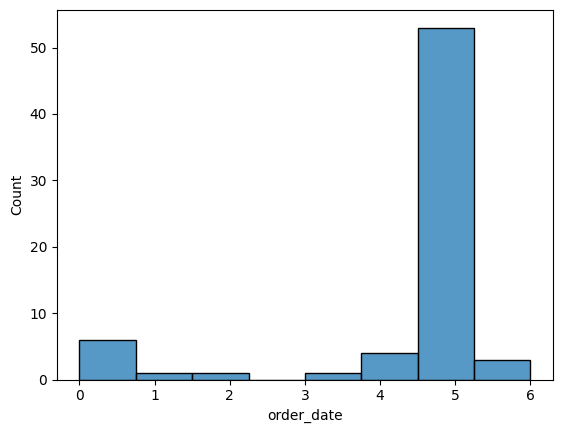

In [5]:
# Aggregate total sales by order date
tot_sales_df = sales_df.groupby(['order_date'])['revenue'].sum().reset_index()
tot_sales_df.columns = ['order_date', 'total_sales']

# Fill in missing dates
tot_sales_df.set_index('order_date', inplace=True)
tot_sales_df = tot_sales_df.asfreq('D')

# Check days with missing dates
miss_dates = tot_sales_df[tot_sales_df.isna().values].index
sns.histplot(data=miss_dates.day_of_week)

The histogram above represents days of the week as integers (Monday:0, Sunday:6). We observe a large number of missing Saturday dates compared to every other dat of the week. 

We check the number of missing Saturday dates that are not in the original data.  

In [6]:
sat_count = sum(tot_sales_df.index.day_of_week ==5)
missing_sat_count = sum(miss_dates.day_of_week==5)

print("Number of Saturdays in Data: " + str(sat_count-missing_sat_count))

Number of Saturdays in Data: 0


This tells us that no orders on Saturday were recorded indicating orders are not processed or accepted on Saturdays. 

Therefore, we need to create a customer business week with 6 working days excluding Saturdays. Missing dates of all other weekdays should be interpreted as zero orders for that day. 

### Sales Distribution

The following histogram plot shows the distribution of total sales of a category on a single date. 

<Axes: xlabel='total_sales', ylabel='Count'>

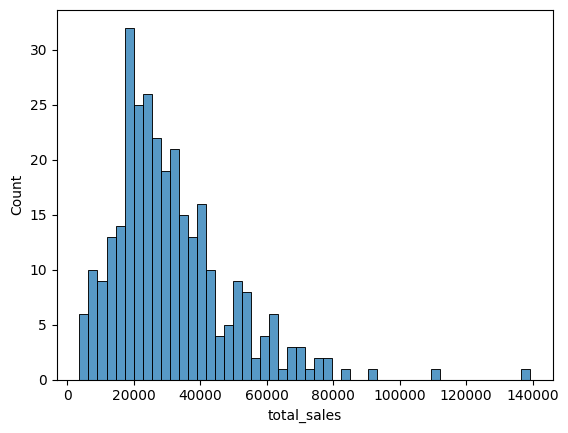

In [7]:
# plot histogram of total sales
sns.histplot(data=tot_sales_df,x='total_sales',bins=50)


Positively skewed distribution with a few distinct outliers above $100000. 

### Sales Time Series

The next line plot shows total sales over time followed by a a line plot hued by each category. 

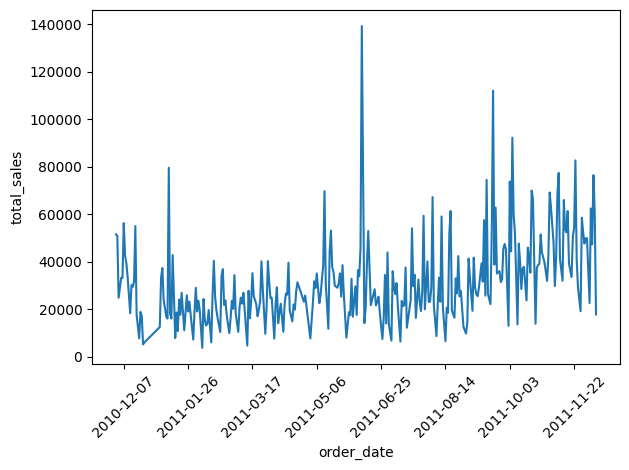

In [8]:
# Plot total sales over time
ax = sns.lineplot(data=tot_sales_df, x='order_date', y='total_sales')

ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=45)
plt.tight_layout()

We make the following general observations:
- Downward trend at the conclusion of the 2010 year followed by steady sales until an increase towards the end of 2011 year. 
- Similar total sales observed at the end of both 2010 and 2011 (ignoring the spike on the latest date). Indicates seasonal yearly trend. 
- Regular minor spikes in sales indicating cyclical behavior. 


More importantly, we have:
- Missing data around mid December 2010 to early January 2011. 
- A major outlier on the last day.

Both will need to be addressed using imputation methods. The last outlier will cause forecasting issues since the forecast value (usually a mean value) will begin on an outlier. 



## Time Series Analysis

In this section, we perform an analysis to determine asses the validity and optimise parameters for an ARIMA model as well as a prophet model. 

To fit an ARIMA models we need: 
- Stationary testing
- Applying transformation and differencing if required
- ACF / PACF analysis

We conclude that a suitable candidate for our ARIMA model should be:
- AR(0)
- I(1)
- MA(1)

### Preprocessing

To fit a model, we need to create a time series that addresses the following issues raised by the EDA: 
1. Total sales aggregated by order date to create a time series with a daily frequency following as custom business week described above (6 days, excluding Saturday). 
2. Imputing missing dates around mid December 2010 to early January 2011. 
3. Imputing the outlier in the last recorded date. 

Both imputations are done using a rolling average. 

<Axes: xlabel='date'>

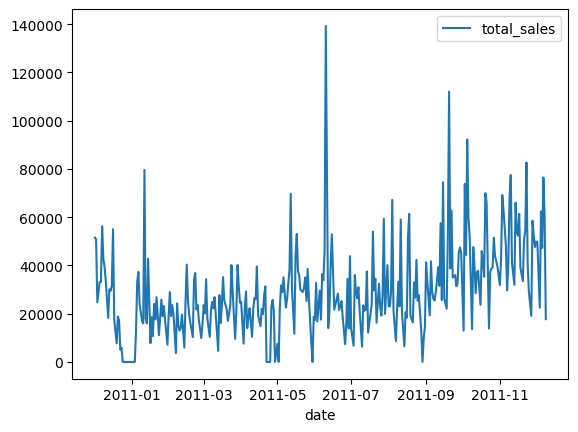

In [9]:
# --- Create Time Series --- #

# Aggregate total sales by order date
sales_ts = sales_df.groupby('order_date')['revenue'].sum().reset_index()
sales_ts.columns = ['date','total_sales'] 

# Define customer business week (excludes Saturdays)
from pandas.tseries.offsets import CustomBusinessDay
custom_business = CustomBusinessDay(weekmask='Mon Tue Wed Thu Fri Sun')  # exclude Saturday

# Create datetime index with daily frequency
sales_ts.set_index('date', inplace=True)
sales_ts = sales_ts.resample(custom_business).asfreq(fill_value=0)

sns.lineplot(data=sales_ts)

<Axes: xlabel='date'>

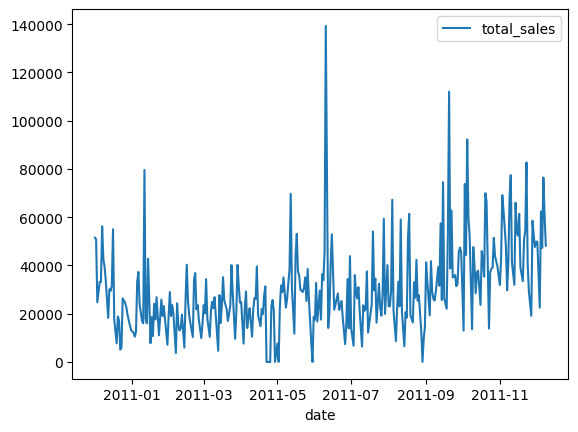

In [10]:
# --- Impute Data --- #


# Impute last outlier value with weekly average
sales_ts.iloc[-1] = sales_ts.iloc[-7:].mean()

# Fill missing dates rolling average 
start_missing = pd.to_datetime("2010-12-24")
end_missing = pd.to_datetime("2011-01-03")

missing_range = pd.date_range(
    start=start_missing,
    end=end_missing,
    freq=custom_business
    )

T_delta = 2*len(missing_range) # rolling average window chosen to be double number of missing days

# Compute range to use for rolling mean
rolling_range =  pd.date_range(
    start=start_missing - pd.Timedelta(days=T_delta+1),
    end=end_missing + pd.Timedelta(days=T_delta-1),
    freq=custom_business
    )

# Impute
rolling = sales_ts.loc[rolling_range].rolling(T_delta).mean()
sales_ts.loc[missing_range] = rolling.loc[missing_range]

sns.lineplot(data=sales_ts)

### Stationary Check  

We use the ADF test to detect unit roots. The adfuller from 'statsmodels' test for the null hypothesis that there exists a unit root (time series is not stationary). 

In [11]:
# --- ADF Test for Stationary Data --- #
result = adfuller(sales_ts)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.720570895140368
p-value: 0.420546109854139


Based on the ADF test, we accept the null hypothesis and conclude that the time series is not stationary. We apply a differencing and retest. 

In [12]:
# First order differencing then retest
sales_ts_diff = sales_ts.diff(periods=1).dropna()

result_diff = adfuller(sales_ts_diff)
print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic: -8.652029534517121
p-value: 5.084859372902877e-14


After a single difference, the time series appears to be stationary.  

### Autocorrelation and Partial Autocorrelation

We look at autocorrelation and partial autocorrelation test to determine the parameters of the ARIMA model. 

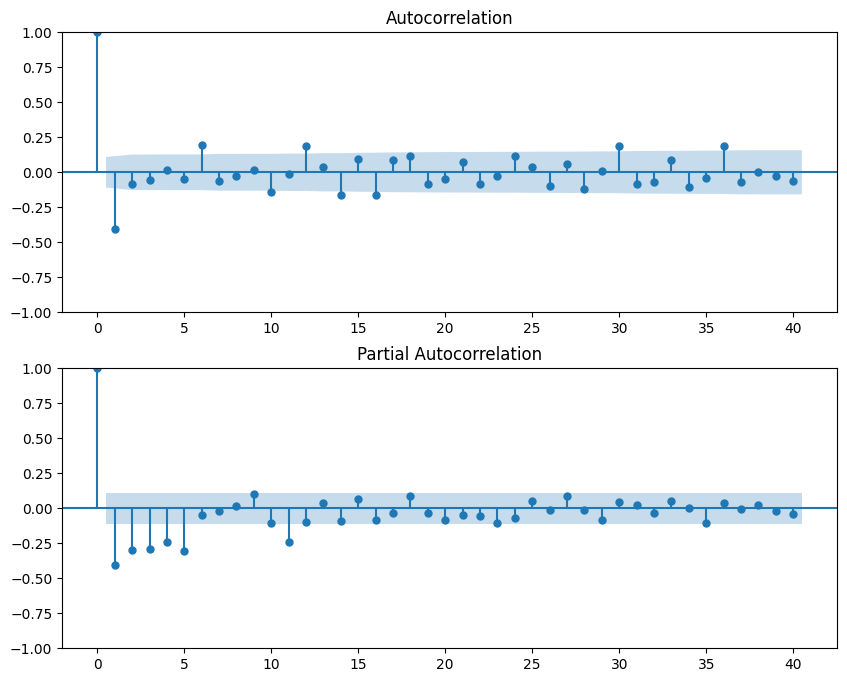

In [13]:
# --- ACF and PACF Plots --- #

fig, ax = plt.subplots(2,1, figsize=(10,8))
plot_acf(sales_ts_diff['total_sales'], lags=40, ax=ax[0])
plot_pacf(sales_ts_diff['total_sales'], lags=40, ax=ax[1])   

plt.show()

From the plots above, we observe: 
- ACF plot has a cutoff at 1 indicating significant first lag. 
- ACF plot has significant lags at every 6 intervals indicating seasonality. 
- PACF demonstrates slow decay wit the exception of lag 5 and 11. Increase partial autocorrelation at 5 and 11 possibly due to seasonality. 

Based on the 6 (7 for without differencing) day seasonality we apply a SARIMA. The significant lags in the ACF and PACF plots suggest the following parameters:  
- AR(0)
- I(1)
- MA(1)

## Modelling and Evaluation

This section has two goals. Fit SARIMA and a prophet model. Each model is evaluated using residuals and autocorrelation. 

### SARIMA model and Evaluation

We add a seasonal component by fitting a SARIMA model. 

In [14]:
# Fit SARIMA model
sarima_model = sarima(
    sales_ts['total_sales'], 
    order=(0,1,1), 
    seasonal_order=(1,1,1,6),
    freq=custom_business
    )
sarima_fit = sarima_model.fit()
sarima_fit.summary()

/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                       total_sales   No. Observations:                  321
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 6)   Log Likelihood               -3468.852
Date:                           Tue, 31 Mar 2026   AIC                           6945.704
Time:                                   16:46:51   BIC                           6960.701
Sample:                               12-01-2010   HQIC                          6951.696
                                    - 12-09-2011                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8150      0.034    -24.156      0.000      -0.881      -0.749
ar.S.L6        0.0053      0.052      0.103      0.918      -0.096       0.106
ma.S.L6       -0.9991      0.035    -28.620      0.000      -1.067      -0.931
sigma2      2.163e+08   1.63e-10   1.32e+18      0.000    2.16e+08    2.16e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):              1805.26
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               1.97   Skew:                             2.06
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.02e+33. Standard errors may be unstable.
"""

We see an AIC and BIC scores of 7081.698 and 7096.696 respectively.

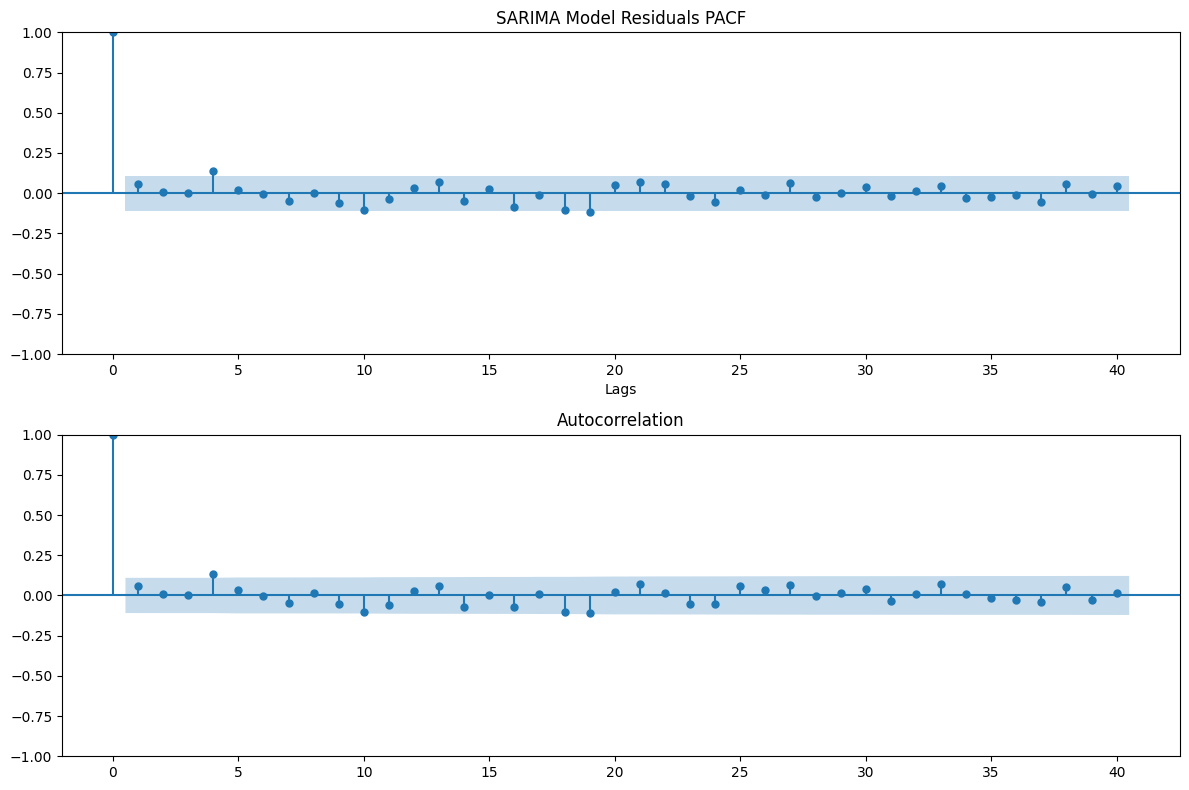

In [15]:
# Plot SARIMA residuals ACF
fig, ax = plt.subplots(2,1,figsize=(12,8))

plot_acf(sarima_fit.resid, lags=40, ax=ax[1])
ax[0].set_title('SARIMA Model Residuals ACF')
ax[0].set_xlabel('Lags')

plot_pacf(sarima_fit.resid, lags=40, ax=ax[0])
ax[0].set_title('SARIMA Model Residuals PACF')
ax[0].set_xlabel('Lags')

plt.tight_layout()
plt.show()

The ACF of SARIMA residuals show no significant lags strongly suggesting that the residuals is white noise. 

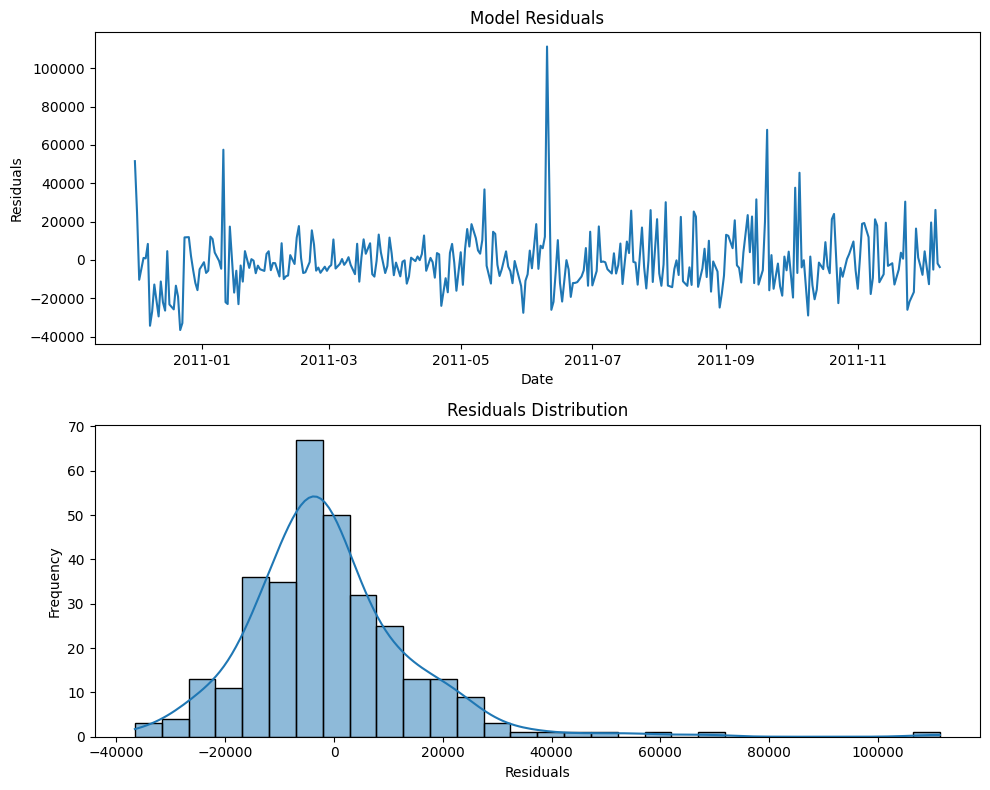

In [16]:
# Plot residuals
fig, ax = plt.subplots(2,1, figsize=(10,8))

# Residual line plots 
sns.lineplot(data=sarima_fit.resid,ax=ax[0])
ax[0].set_title('Model Residuals')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Residuals')

# Histogram of residuals
sns.histplot(data=sarima_fit.resid, bins=30, kde=True, ax=ax[1])
ax[1].set_title('Residuals Distribution')
ax[1].set_xlabel('Residuals')
ax[1].set_ylabel('Frequency')

fig.tight_layout()
plt.show()


We observe the following:
- Residual time series resembles white noise.
- The residuals follow a normal distribution that is slightly right skewed due to outliers. 

Based on this, we accept th model and proceed to forecast the sales. 

### Prophet

Similarly, we fit a prophet model as an alternative model. 

In [17]:
prophet_df = sales_ts.reset_index()[['date','total_sales']].rename(columns={'date':'ds','total_sales':'y'})

model = Prophet(
    daily_seasonality=False,   # too granular for retail revenue patterns
    weekly_seasonality=True,   # day-of-week effects are strong in retail
    yearly_seasonality=True,   # limited by dataset length but retain
    interval_width=0.95        # 95% confidence intervals
)

model.fit(prophet_df)


16:46:51 - cmdstanpy - INFO - Chain [1] start processing
16:46:51 - cmdstanpy - INFO - Chain [1] done processing


## Forecasting

We forecast 14 days into the future and save the resulting forecast in `data/analysis/sales_ts.parquet`. This wil be included in a sales analysis dashboard in PowerBI. 

(array([14975., 15034., 15095., 15156., 15218., 15279., 15340.]),
 [Text(14975.0, 0, '2011-01'),
  Text(15034.0, 0, '2011-03'),
  Text(15095.0, 0, '2011-05'),
  Text(15156.0, 0, '2011-07'),
  Text(15218.0, 0, '2011-09'),
  Text(15279.0, 0, '2011-11'),
  Text(15340.0, 0, '2012-01')])

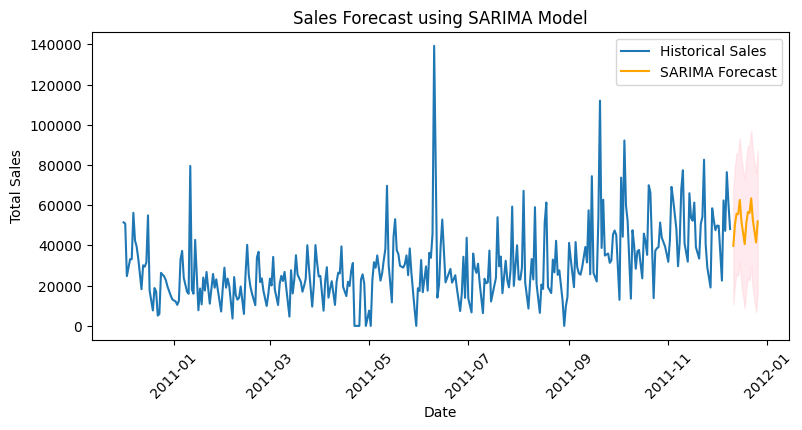

In [18]:
# Forecast with SARIMA model
forecast_steps = 14 # two week daily forecast
forecast_dates = pd.date_range(
    start=sales_ts.index[-1] + pd.Timedelta(days=1), 
    freq=custom_business,
    periods=forecast_steps
    )
sarima_forecast = sarima_fit.get_forecast(steps=forecast_steps)

y_mean = sarima_forecast.predicted_mean
ci = sarima_forecast.conf_int()

# Plot the results
fig, ax = plt.subplots(figsize=(9,4))

sns.lineplot(data=sales_ts, x=sales_ts.index, y='total_sales', label='Historical Sales', ax=ax)
sns.lineplot(x=forecast_dates, y=y_mean, label='SARIMA Forecast', color='orange', ax=ax)
plt.fill_between(x=forecast_dates, y1=ci.iloc[:,0],y2=ci.iloc[:,1], color='pink', alpha=0.3)

ax.set_title('Sales Forecast using SARIMA Model')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')

plt.xticks(rotation=45)


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1565: Runt

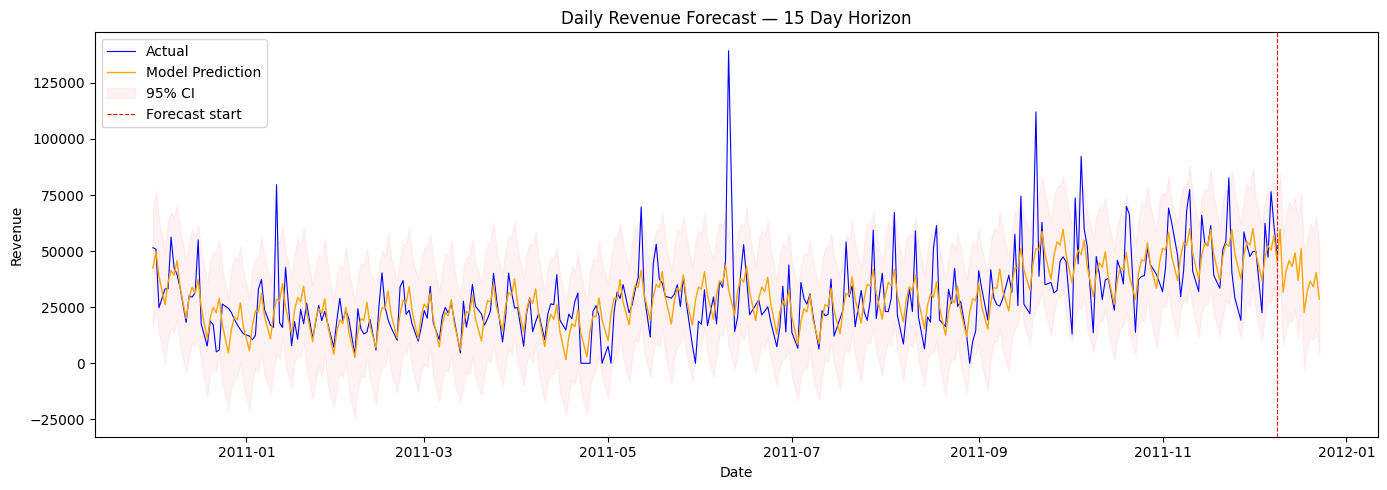

In [19]:
# Forecast with Prophet Model

future = model.make_future_dataframe(periods=forecast_steps, freq='D')
forecast = model.predict(future)

# Record results 
results = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
historical = results[results['ds'] <= prophet_df['ds'].max()]
forward    = results[results['ds'] >  prophet_df['ds'].max()]

# Plot 
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prophet_df['ds'], prophet_df['y'], color='blue', linewidth=0.8, label='Actual') # plot historical
ax.plot(results['ds'], results['yhat'], color='orange', linewidth=1, label='Model Prediction') # plot model predictions
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'], # plot confidence interval
                alpha=0.2, color='pink', label='95% CI')

# Additional Plot Features
ax.axvline(prophet_df['ds'].max(), color='red', linestyle='--', linewidth=0.8, label='Forecast start') # mark start of forecast
ax.set_title('Daily Revenue Forecast — 15 Day Horizon')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.show()



We opt for the ARIMA model to forecast our results. The data set spans for a year from which Prophet is unable to capture the yearly seasonal trend. 

In [20]:
# Create forecasted series
forecast_series = pd.DataFrame(
    data=y_mean.values, 
    index=forecast_dates,
    columns=['total_sales']
    )

# Add type to distinguish historical and forecasted data
sales_ts['type'] = 'historical'
forecast_series['type'] = 'forecast'

res_ts = pd.concat([sales_ts,forecast_series])

# Save sales data
OUT_DIR = '../data/analysis'
res_ts.to_parquet(OUT_DIR + "/sales_ts.parquet")

